In [12]:
# ============================================================
# PIPELINE HRV - RECUPERADO / NO_RECUPERADO
# Windowing + Features HRV + Recovery Score + Sintéticos + MLP
# ============================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import skew, kurtosis

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================

USE_COLAB = True   # True si usas Colab, False si usas VSCode/laptop

if USE_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        print("Drive ya está montado o no estás usando Colab.")

    BASE_DIR = "/content/drive/MyDrive/Proyecto_HRV"

else:
    BASE_DIR = r"C:\Users\lbrya\OneDrive\Escritorio\Proyecto_HRV"


DATA_DIR = os.path.join(BASE_DIR, "data_raw")
METADATA_DIR = os.path.join(BASE_DIR, "metadata")
OUT_DIR = os.path.join(BASE_DIR, "outputs")
QC_DIR = os.path.join(OUT_DIR, "qc_picos_R")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(QC_DIR, exist_ok=True)

# Parámetros de señal
FS_HZ = 1000
ECG_COL_INDEX = -1

# Windowing
WINDOW_SEC = 30
STEP_SEC = 15

# Data sintética
N_SYNTH_PER_REAL = 3
NOISE_LEVEL = 0.12

# Umbral exploratorio para definir recuperación
RECOVERY_THRESHOLD = 60

STATE_ORDER = ["basal", "cognitivo", "recuperacion"]

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/Proyecto_HRV
DATA_DIR: /content/drive/MyDrive/Proyecto_HRV/data_raw
OUT_DIR: /content/drive/MyDrive/Proyecto_HRV/outputs


In [13]:
# ============================================================
# 2. LECTURA DE ARCHIVOS
# ============================================================

def show_df(df, n=5):
    try:
        display(df.head(n))
    except Exception:
        print(df.head(n))


def read_numeric_file(path, ecg_col_index=-1):
    """
    Lee archivos .txt, .csv o .tsv con separador flexible.
    """

    df = pd.read_csv(
        path,
        comment="#",
        header=None,
        sep=r"[\s,;]+",
        engine="python"
    )

    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=1, how="all")

    if df.shape[1] == 0:
        raise ValueError(f"No se encontraron columnas numéricas en: {path}")

    if ecg_col_index == -1:
        signal = df.iloc[:, -1].dropna().values
    else:
        signal = df.iloc[:, ecg_col_index].dropna().values

    return signal.astype(float)


def build_file_table(data_dir):
    """
    Detecta archivos ECG y asigna estado según nombre de archivo o carpeta.
    """

    state_aliases = {
        "basal": ["basal", "reposo", "rest"],
        "cognitivo": ["cognitivo", "cognitiva", "tarea", "task", "2back", "nback"],
        "recuperacion": ["recuperacion", "recuperación", "recovery", "post", "rec"]
    }

    rows = []

    participant_dirs = sorted([
        d for d in glob.glob(os.path.join(data_dir, "*"))
        if os.path.isdir(d)
    ])

    for pdir in participant_dirs:
        participant = os.path.basename(pdir)

        files = []
        files.extend(glob.glob(os.path.join(pdir, "*.txt")))
        files.extend(glob.glob(os.path.join(pdir, "*.csv")))
        files.extend(glob.glob(os.path.join(pdir, "*.tsv")))

        files.extend(glob.glob(os.path.join(pdir, "*", "*.txt")))
        files.extend(glob.glob(os.path.join(pdir, "*", "*.csv")))
        files.extend(glob.glob(os.path.join(pdir, "*", "*.tsv")))

        for file_path in files:
            fname = os.path.basename(file_path).lower()
            parent = os.path.basename(os.path.dirname(file_path)).lower()
            text_to_check = fname + " " + parent

            detected_state = None

            for state, aliases in state_aliases.items():
                if any(alias in text_to_check for alias in aliases):
                    detected_state = state
                    break

            if detected_state is not None:
                rows.append({
                    "participant": participant,
                    "state": detected_state,
                    "path": file_path
                })

    file_table = pd.DataFrame(rows)

    if file_table.empty:
        raise ValueError("No se detectaron archivos. Revisa data_raw y los nombres de archivos.")

    return file_table


file_table = build_file_table(DATA_DIR)

print("Archivos detectados:")
show_df(file_table, n=20)

print("\nResumen por participante y estado:")
try:
    display(file_table.groupby(["participant", "state"]).size().reset_index(name="n_archivos"))
except Exception:
    print(file_table.groupby(["participant", "state"]).size())

Archivos detectados:


,participant,state,path
0,P01,basal,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
1,P01,cognitivo,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
2,P01,recuperacion,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
3,P02,basal,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
4,P02,cognitivo,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
5,P02,recuperacion,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
6,P03,basal,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
7,P03,cognitivo,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...
8,P03,recuperacion,/content/drive/MyDrive/Proyecto_HRV/data_raw/P...



Resumen por participante y estado:


,participant,state,n_archivos
0,P01,basal,1
1,P01,cognitivo,1
2,P01,recuperacion,1
3,P02,basal,1
4,P02,cognitivo,1
5,P02,recuperacion,1
6,P03,basal,1
7,P03,cognitivo,1
8,P03,recuperacion,1


In [14]:
# ============================================================
# 3. FILTRADO Y DETECCIÓN DE PICOS R
# ============================================================

def bandpass_filter(x, fs, low=5, high=20, order=3):
    """
    Filtro pasa banda para resaltar complejo QRS.
    """

    x = np.asarray(x, dtype=float)

    nyq = fs / 2
    high = min(high, nyq * 0.8)

    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    y = filtfilt(b, a, x)

    return y


def zscore(x):
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-8)


def detect_r_peaks(ecg, fs, prominence=0.8):

    ecg = np.asarray(ecg, dtype=float)
    ecg = ecg - np.nanmedian(ecg)

    # Filtrado QRS
    filtered = bandpass_filter(ecg, fs, low=5, high=20, order=3)
    filtered_z = zscore(filtered)

    # Envolvente absoluta: sirve aunque el QRS sea positivo o negativo
    envelope = np.abs(filtered_z)

    # Suavizado corto de la envolvente
    smooth_win = max(1, int(0.08 * fs))  # 80 ms
    kernel = np.ones(smooth_win) / smooth_win
    envelope_smooth = np.convolve(envelope, kernel, mode="same")

    # Distancia mínima más fisiológica
    # 0.45 s equivale a permitir hasta aprox. 133 bpm
    min_distance = int(0.45 * fs)

    # Umbral robusto con mediana y MAD
    med = np.median(envelope_smooth)
    mad = np.median(np.abs(envelope_smooth - med)) + 1e-8
    height_threshold = med + 3.0 * mad

    candidate_peaks, _ = find_peaks(
        envelope_smooth,
        distance=min_distance,
        height=height_threshold
    )

    duration_sec = len(ecg) / fs
    min_expected_beats = duration_sec * 40 / 60

    # Si detecta muy pocos, relaja el criterio
    if len(candidate_peaks) < min_expected_beats:
        candidate_peaks, _ = find_peaks(
            envelope_smooth,
            distance=min_distance,
            prominence=prominence
        )

    # Refinamiento: buscar el máximo absoluto del QRS cerca del candidato
    search_radius = int(0.08 * fs)  # ±80 ms
    refined_peaks = []

    for peak in candidate_peaks:
        start = max(0, peak - search_radius)
        end = min(len(filtered_z), peak + search_radius + 1)

        local_segment = filtered_z[start:end]

        if len(local_segment) == 0:
            continue

        local_idx = np.argmax(np.abs(local_segment))
        refined_peak = start + local_idx

        refined_peaks.append(refined_peak)

    refined_peaks = np.array(sorted(set(refined_peaks)), dtype=int)

    # Eliminar duplicados demasiado cercanos conservando el de mayor amplitud absoluta
    if len(refined_peaks) > 1:
        cleaned_peaks = []

        for peak in refined_peaks:
            if len(cleaned_peaks) == 0:
                cleaned_peaks.append(peak)
            else:
                last_peak = cleaned_peaks[-1]

                if peak - last_peak < min_distance:
                    if abs(filtered_z[peak]) > abs(filtered_z[last_peak]):
                        cleaned_peaks[-1] = peak
                else:
                    cleaned_peaks.append(peak)

        refined_peaks = np.array(cleaned_peaks, dtype=int)

    # Ajustar polaridad solo para visualización:
    # queremos que los picos detectados aparezcan hacia arriba en la gráfica
    if len(refined_peaks) > 0:
        median_peak_value = np.median(filtered_z[refined_peaks])

        if median_peak_value < 0:
            filtered_for_plot = -filtered_z
        else:
            filtered_for_plot = filtered_z
    else:
        filtered_for_plot = filtered_z

    return refined_peaks, filtered_for_plot

    def quality_score(peaks, props):
        n = len(peaks)

        if n == 0:
            return -np.inf

        prom = np.median(props.get("prominences", [0]))

        penalty = 0

        if n < min_beats:
            penalty += abs(min_beats - n)

        if n > max_beats:
            penalty += abs(n - max_beats)

        return prom - 0.01 * penalty

    score_pos = quality_score(peaks_pos, props_pos)
    score_neg = quality_score(peaks_neg, props_neg)

    if score_pos >= score_neg:
        return peaks_pos, filtered_z
    else:
        return peaks_neg, -filtered_z

In [15]:
# ============================================================
# 4. FEATURES POR VENTANA
# ============================================================

def compute_window_features(ecg_filtered, peaks, fs, start_sec, end_sec):
    """
    Calcula features HRV y estadísticos por ventana.
    """

    peak_times = peaks / fs

    mask_peaks = (peak_times >= start_sec) & (peak_times < end_sec)
    peaks_win_sec = peak_times[mask_peaks]

    if len(peaks_win_sec) < 5:
        return None

    rr_ms = np.diff(peaks_win_sec) * 1000

    # Filtrado fisiológico simple de RR
    rr_ms = rr_ms[(rr_ms >= 300) & (rr_ms <= 2000)]

    if len(rr_ms) < 4:
        return None

    diff_rr = np.diff(rr_ms)
    hr_inst = 60000 / rr_ms

    start_idx = int(start_sec * fs)
    end_idx = int(end_sec * fs)
    segment = ecg_filtered[start_idx:end_idx]

    if len(segment) == 0:
        return None

    features = {
        "HR_mean": np.mean(hr_inst),
        "HR_min": np.min(hr_inst),
        "HR_max": np.max(hr_inst),

        "RR_mean": np.mean(rr_ms),
        "RR_median": np.median(rr_ms),

        "SDNN": np.std(rr_ms, ddof=1),
        "RMSSD": np.sqrt(np.mean(diff_rr ** 2)),
        "pNN50": np.mean(np.abs(diff_rr) > 50) * 100,

        "NN_count": len(rr_ms),

        "ECG_mean": np.mean(segment),
        "ECG_std": np.std(segment),
        "ECG_rms": np.sqrt(np.mean(segment ** 2)),
        "ECG_ptp": np.ptp(segment),
        "ECG_energy": np.sum(segment ** 2) / len(segment),
        "ECG_skew": skew(segment),
        "ECG_kurtosis": kurtosis(segment)
    }

    return features


def extract_features_from_file(
    path,
    participant,
    state,
    fs,
    window_sec,
    step_sec,
    ecg_col_index=-1
):
    """
    Extrae features HRV por ventanas desde un archivo ECG.
    """

    ecg = read_numeric_file(path, ecg_col_index=ecg_col_index)
    peaks, filtered = detect_r_peaks(ecg, fs)

    duration_sec = len(ecg) / fs

    rows = []
    window_id = 0

    for start_sec in np.arange(0, duration_sec - window_sec + 1, step_sec):
        end_sec = start_sec + window_sec
        window_id += 1

        feats = compute_window_features(
            ecg_filtered=filtered,
            peaks=peaks,
            fs=fs,
            start_sec=start_sec,
            end_sec=end_sec
        )

        if feats is None:
            continue

        row = {
            "participant": participant,
            "state": state,
            "file": os.path.basename(path),
            "window_id": window_id,
            "window_start_sec": start_sec,
            "window_end_sec": end_sec,
            "duration_file_sec": duration_sec,
            "n_peaks_total": len(peaks),
            "synthetic": False
        }

        row.update(feats)
        rows.append(row)

    return pd.DataFrame(rows), ecg, peaks, filtered

Procesando: P01 | basal | P01_basal_ECGv2.txt
  Duración: 5.04 min | Ventanas válidas: 19


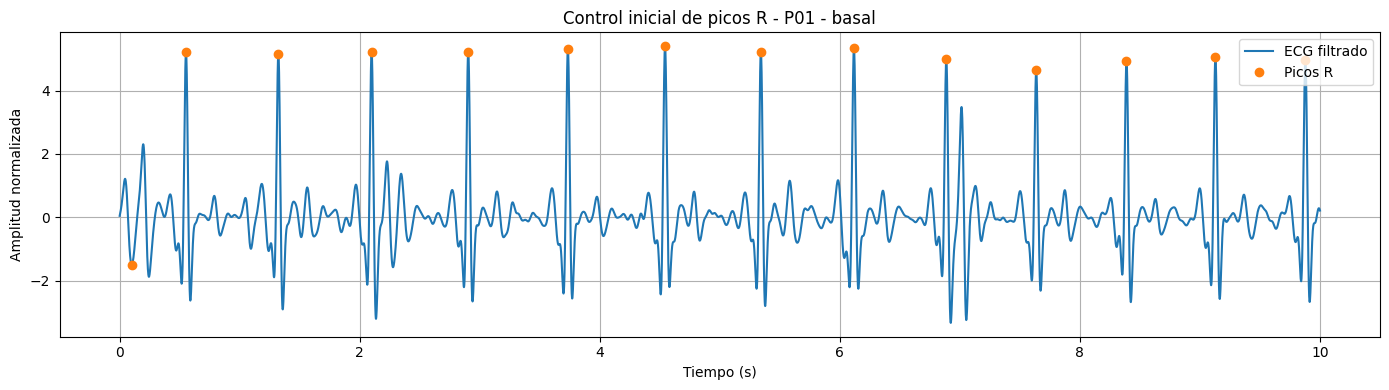

Procesando: P01 | cognitivo | P01_cognitiva_ECGv2.txt
  Duración: 5.08 min | Ventanas válidas: 19
Procesando: P01 | recuperacion | P01_recuperacion_ECGv2.txt
  Duración: 5.09 min | Ventanas válidas: 19
Procesando: P02 | basal | P02_basal_ECGv2.h5.txt
  Duración: 5.10 min | Ventanas válidas: 19
Procesando: P02 | cognitivo | P02_cognitiva_ECGv2.h5.txt
  Duración: 4.39 min | Ventanas válidas: 16
Procesando: P02 | recuperacion | P02_recuperacion_ECGv2.txt.txt
  Duración: 5.04 min | Ventanas válidas: 19
Procesando: P03 | basal | P03_basal_ECGv2.txt
  Duración: 3.71 min | Ventanas válidas: 13
Procesando: P03 | cognitivo | P03_cognitiva_ECGv2.txt
  Duración: 3.93 min | Ventanas válidas: 14
Procesando: P03 | recuperacion | P03_recuperacion_ECGv2.txt
  Duración: 4.58 min | Ventanas válidas: 17

Features reales:


,participant,state,file,window_id,window_start_sec,window_end_sec,duration_file_sec,n_peaks_total,synthetic,HR_mean,...,RMSSD,pNN50,NN_count,ECG_mean,ECG_std,ECG_rms,ECG_ptp,ECG_energy,ECG_skew,ECG_kurtosis
0,P01,basal,P01_basal_ECGv2.txt,1,0.0,30.0,302.7,363,False,78.812779,...,57.915362,8.108108,38,0.001093,1.077766,1.077766,8.978856,1.161580,1.809471,8.171182
1,P01,basal,P01_basal_ECGv2.txt,2,15.0,45.0,302.7,363,False,77.940855,...,25.668890,5.405405,38,0.000173,1.064791,1.064791,9.093754,1.133781,1.908420,8.751274
2,P01,basal,P01_basal_ECGv2.txt,3,30.0,60.0,302.7,363,False,80.108498,...,21.302953,0.000000,39,0.000015,1.057935,1.057935,8.985186,1.119227,1.851202,8.370167
3,P01,basal,P01_basal_ECGv2.txt,4,45.0,75.0,302.7,363,False,76.592661,...,27.263121,11.111111,37,-0.000241,1.014979,1.014979,8.465313,1.030182,1.983636,9.414823
4,P01,basal,P01_basal_ECGv2.txt,5,60.0,90.0,302.7,363,False,67.873798,...,28.817313,15.625000,33,-0.000881,0.965018,0.965018,8.422561,0.931260,2.142459,11.145597
5,P01,basal,P01_basal_ECGv2.txt,6,75.0,105.0,302.7,363,False,66.653994,...,29.045570,9.677419,32,0.000069,0.962757,0.962757,8.390051,0.926900,2.158197,11.493476
6,P01,basal,P01_basal_ECGv2.txt,7,90.0,120.0,302.7,363,False,68.417150,...,32.843854,9.375000,33,-0.000230,0.975482,0.975482,8.390051,0.951565,2.151171,11.189433
7,P01,basal,P01_basal_ECGv2.txt,8,105.0,135.0,302.7,363,False,69.591817,...,35.624302,12.121212,34,-0.000632,0.987944,0.987944,8.435191,0.976033,2.136769,10.907145
8,P01,basal,P01_basal_ECGv2.txt,9,120.0,150.0,302.7,363,False,68.949384,...,38.361913,21.212121,34,0.000038,1.001943,1.001943,8.560215,1.003889,2.119079,10.806166
9,P01,basal,P01_basal_ECGv2.txt,10,135.0,165.0,302.7,363,False,70.725377,...,31.484003,12.121212,34,0.000064,1.010566,1.010566,8.509424,1.021243,2.110640,10.639448



Resumen por archivo:


,participant,state,file,duration_sec,duration_min,n_peaks_total,expected_windows_by_duration,valid_windows_extracted,estimated_HR_global_bpm
0,P01,basal,P01_basal_ECGv2.txt,302.70,5.0450,363,19,19,71.952428
1,P01,cognitivo,P01_cognitiva_ECGv2.txt,305.10,5.0850,380,19,19,74.729597
2,P01,recuperacion,P01_recuperacion_ECGv2.txt,305.40,5.0900,363,19,19,71.316306
3,P02,basal,P02_basal_ECGv2.h5.txt,306.15,5.1025,400,19,19,78.392945
4,P02,cognitivo,P02_cognitiva_ECGv2.h5.txt,263.40,4.3900,363,16,16,82.687927
5,P02,recuperacion,P02_recuperacion_ECGv2.txt.txt,302.70,5.0450,390,19,19,77.304262
6,P03,basal,P03_basal_ECGv2.txt,222.60,3.7100,247,13,13,66.576819
7,P03,cognitivo,P03_cognitiva_ECGv2.txt,235.95,3.9325,286,14,14,72.727273
8,P03,recuperacion,P03_recuperacion_ECGv2.txt,274.50,4.5750,318,17,17,69.508197



Ventanas por participante y estado:


,participant,state,n_ventanas
0,P01,basal,19
1,P01,cognitivo,19
2,P01,recuperacion,19
3,P02,basal,19
4,P02,cognitivo,16
5,P02,recuperacion,19
6,P03,basal,13
7,P03,cognitivo,14
8,P03,recuperacion,17



Guardado:
/content/drive/MyDrive/Proyecto_HRV/outputs/00_resumen_archivos_crudos.csv
/content/drive/MyDrive/Proyecto_HRV/outputs/01_features_reales_HRV.csv


In [16]:
# ============================================================
# 5. PROCESAR TODOS LOS ECG REALES
# ============================================================

all_features = []
raw_qc_rows = []

first_plot_done = False

for _, row in file_table.iterrows():

    participant = row["participant"]
    state = row["state"]
    path = row["path"]

    print(f"Procesando: {participant} | {state} | {os.path.basename(path)}")

    features_file_df, ecg, peaks, filtered = extract_features_from_file(
        path=path,
        participant=participant,
        state=state,
        fs=FS_HZ,
        window_sec=WINDOW_SEC,
        step_sec=STEP_SEC,
        ecg_col_index=ECG_COL_INDEX
    )

    duration_sec = len(ecg) / FS_HZ
    n_expected_windows = int(np.floor((duration_sec - WINDOW_SEC) / STEP_SEC) + 1) if duration_sec >= WINDOW_SEC else 0

    raw_qc_rows.append({
        "participant": participant,
        "state": state,
        "file": os.path.basename(path),
        "duration_sec": duration_sec,
        "duration_min": duration_sec / 60,
        "n_peaks_total": len(peaks),
        "expected_windows_by_duration": n_expected_windows,
        "valid_windows_extracted": len(features_file_df),
        "estimated_HR_global_bpm": len(peaks) / duration_sec * 60 if duration_sec > 0 else np.nan
    })

    if features_file_df.empty:
        print("  Advertencia: no se extrajeron ventanas válidas.")
    else:
        print(f"  Duración: {duration_sec/60:.2f} min | Ventanas válidas: {len(features_file_df)}")
        all_features.append(features_file_df)

    # Plot inicial
    if not first_plot_done:
        t = np.arange(len(filtered)) / FS_HZ
        max_sec_plot = min(10, len(filtered) / FS_HZ)

        mask_plot = t <= max_sec_plot
        peaks_plot = peaks[(peaks / FS_HZ) <= max_sec_plot]

        plt.figure(figsize=(14, 4))
        plt.plot(t[mask_plot], filtered[mask_plot], label="ECG filtrado")
        plt.plot(peaks_plot / FS_HZ, filtered[peaks_plot], "o", label="Picos R")
        plt.xlabel("Tiempo (s)")
        plt.ylabel("Amplitud normalizada")
        plt.title(f"Control inicial de picos R - {participant} - {state}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        first_plot_done = True


if len(all_features) == 0:
    raise RuntimeError("No se extrajeron features de ningún archivo.")


features_real_df = pd.concat(all_features, ignore_index=True)
raw_qc_df = pd.DataFrame(raw_qc_rows)

print("\nFeatures reales:")
show_df(features_real_df, n=10)

print("\nResumen por archivo:")
try:
    display(raw_qc_df)
except Exception:
    print(raw_qc_df)

print("\nVentanas por participante y estado:")
windows_summary = (
    features_real_df
    .groupby(["participant", "state"])
    .size()
    .reset_index(name="n_ventanas")
)

try:
    display(windows_summary)
except Exception:
    print(windows_summary)


raw_qc_path = os.path.join(OUT_DIR, "00_resumen_archivos_crudos.csv")
features_path = os.path.join(OUT_DIR, "01_features_reales_HRV.csv")

raw_qc_df.to_csv(raw_qc_path, index=False)
features_real_df.to_csv(features_path, index=False)

print("\nGuardado:")
print(raw_qc_path)
print(features_path)

In [17]:
# ============================================================
# 6. QC VISUAL DE PICOS R POR ARCHIVO
# ============================================================

for _, row in file_table.iterrows():

    participant = row["participant"]
    state = row["state"]
    path = row["path"]

    ecg = read_numeric_file(path, ecg_col_index=ECG_COL_INDEX)
    peaks, filtered = detect_r_peaks(ecg, FS_HZ)

    t = np.arange(len(filtered)) / FS_HZ
    max_sec_plot = min(10, len(filtered) / FS_HZ)

    mask_plot = t <= max_sec_plot
    peaks_plot = peaks[(peaks / FS_HZ) <= max_sec_plot]

    plt.figure(figsize=(14, 4))
    plt.plot(t[mask_plot], filtered[mask_plot], label="ECG filtrado")
    plt.plot(peaks_plot / FS_HZ, filtered[peaks_plot], "o", label="Picos R detectados")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud normalizada")
    plt.title(f"QC picos R - {participant} - {state}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    fig_name = f"QC_{participant}_{state}_picosR.png"
    fig_path = os.path.join(QC_DIR, fig_name)

    plt.savefig(fig_path, dpi=300)
    plt.close()

print("QC visual guardado en:")
print(QC_DIR)


# ============================================================
# QC NUMÉRICO
# ============================================================

qc_summary = (
    features_real_df
    .groupby(["participant", "state"])
    .agg(
        n_ventanas=("window_id", "count"),
        duration_min_prom=("duration_file_sec", lambda x: np.mean(x) / 60),
        HR_mean_prom=("HR_mean", "mean"),
        HR_mean_mediana=("HR_mean", "median"),
        HR_min_global=("HR_min", "min"),
        HR_max_global=("HR_max", "max"),
        RR_mean_prom=("RR_mean", "mean"),
        SDNN_mediana=("SDNN", "median"),
        RMSSD_mediana=("RMSSD", "median"),
        pNN50_mediana=("pNN50", "median"),
        NN_count_min=("NN_count", "min"),
        NN_count_max=("NN_count", "max")
    )
    .reset_index()
)

print("Resumen QC:")
try:
    display(qc_summary)
except Exception:
    print(qc_summary)


suspicious_df = features_real_df[
    (features_real_df["HR_max"] > 190) |
    (features_real_df["HR_mean"] > 130) |
    (features_real_df["HR_mean"] < 45) |
    (features_real_df["NN_count"] < 18)
].copy()

print("\nVentanas sospechosas:", len(suspicious_df))

qc_summary_path = os.path.join(OUT_DIR, "00_control_calidad_features.csv")
suspicious_path = os.path.join(OUT_DIR, "00_ventanas_sospechosas.csv")

qc_summary.to_csv(qc_summary_path, index=False)
suspicious_df.to_csv(suspicious_path, index=False)

print("Guardado:")
print(qc_summary_path)
print(suspicious_path)

QC visual guardado en:
/content/drive/MyDrive/Proyecto_HRV/outputs/qc_picos_R
Resumen QC:


,participant,state,n_ventanas,duration_min_prom,HR_mean_prom,HR_mean_mediana,HR_min_global,HR_max_global,RR_mean_prom,SDNN_mediana,RMSSD_mediana,pNN50_mediana,NN_count_min,NN_count_max
0,P01,basal,19,5.0450,72.268774,71.218197,58.139535,132.743363,836.572582,49.512803,27.646402,8.108108,32,39
1,P01,cognitivo,19,5.0850,75.042104,75.409380,62.111801,121.212121,803.929995,37.076881,21.766706,0.000000,33,40
2,P01,recuperacion,19,5.0900,71.588416,70.471141,56.232427,89.285714,844.774334,45.973951,30.926552,11.764706,31,39
3,P02,basal,19,5.1025,78.509938,78.426247,70.339977,86.956522,765.500634,26.737238,20.554805,0.000000,37,40
4,P02,cognitivo,16,4.3900,82.714404,82.793531,67.796610,100.334448,728.572115,36.652769,25.133849,5.064103,38,42
5,P02,recuperacion,19,5.0450,77.176091,77.568803,66.152150,116.504854,779.580822,28.773024,23.060789,0.000000,36,39
6,P03,basal,13,3.7100,66.681060,66.839182,58.593750,83.217753,902.132338,38.627696,53.926156,45.161290,31,34
7,P03,cognitivo,14,3.9325,72.809533,72.485017,65.573770,82.872928,825.832789,36.774380,42.247664,26.050420,34,37
8,P03,recuperacion,17,4.5750,69.797518,69.936139,62.176166,83.217753,861.754946,32.033961,36.671969,21.212121,32,37



Ventanas sospechosas: 0
Guardado:
/content/drive/MyDrive/Proyecto_HRV/outputs/00_control_calidad_features.csv
/content/drive/MyDrive/Proyecto_HRV/outputs/00_ventanas_sospechosas.csv


In [28]:
# ============================================================
# 7. FEATURES RELATIVOS AL BASAL
# ============================================================

def add_baseline_relative_features(df):
    """
    Agrega deltas y ratios respecto al basal promedio del participante.
    """

    df = df.copy()

    baseline_df = df[df["state"] == "basal"]

    if baseline_df.empty:
        print("No hay datos basales.")
        return df

    baseline_features = [
        "HR_mean",
        "RR_mean",
        "SDNN",
        "RMSSD",
        "pNN50"
    ]

    baseline_means = baseline_df.groupby("participant")[baseline_features].mean()

    for feat in baseline_features:

        delta_values = []
        ratio_values = []

        for _, row in df.iterrows():

            participant = row["participant"]

            if participant in baseline_means.index:
                base_value = baseline_means.loc[participant, feat]
                current_value = row[feat]

                delta = current_value - base_value
                ratio = current_value / base_value if base_value != 0 else np.nan
            else:
                delta = np.nan
                ratio = np.nan

            delta_values.append(delta)
            ratio_values.append(ratio)

        df[f"{feat}_delta_basal"] = delta_values
        df[f"{feat}_ratio_basal"] = ratio_values

    return df


features_real_df = add_baseline_relative_features(features_real_df)

baseline_path = os.path.join(OUT_DIR, "01_features_reales_con_baseline.csv")
features_real_df.to_csv(baseline_path, index=False)

print("Features con baseline guardados en:")
print(baseline_path)

Features con baseline guardados en:
/content/drive/MyDrive/Proyecto_HRV/outputs/01_features_reales_con_baseline.csv


In [29]:
# ============================================================
# 8. RECOVERY SCORE Y ETIQUETA BINARIA
# ============================================================

def safe_recovery_percent(value_rec, value_base, value_cog, direction="increase"):
    """
    Calcula porcentaje de recuperación hacia basal.

    direction='increase':
        El feature baja en cognitivo y sube en recuperación.
        Ej: RMSSD, SDNN, RR_mean, pNN50.

    direction='decrease':
        El feature sube en cognitivo y baja en recuperación.
        Ej: HR_mean.
    """

    eps = 1e-8

    if direction == "increase":
        denom = value_base - value_cog
        if abs(denom) < eps:
            return np.nan
        return ((value_rec - value_cog) / denom) * 100

    elif direction == "decrease":
        denom = value_cog - value_base
        if abs(denom) < eps:
            return np.nan
        return ((value_cog - value_rec) / denom) * 100

    else:
        raise ValueError("direction debe ser 'increase' o 'decrease'")


def create_recovery_dataset(features_df, threshold=70):
    """
    Usa basal y cognitivo como referencia.
    Solo etiqueta ventanas del estado recuperación.
    """

    rows = []

    for participant, df_p in features_df.groupby("participant"):

        basal = df_p[df_p["state"] == "basal"]
        cog = df_p[df_p["state"] == "cognitivo"]
        rec = df_p[df_p["state"] == "recuperacion"]

        if basal.empty or cog.empty or rec.empty:
            print(f"Participante {participant} incompleto. Se omite.")
            continue

        base_mean = basal[["HR_mean", "RR_mean", "SDNN", "RMSSD", "pNN50"]].mean()
        cog_mean = cog[["HR_mean", "RR_mean", "SDNN", "RMSSD", "pNN50"]].mean()

        for _, row in rec.iterrows():

            hr_rec = safe_recovery_percent(
                row["HR_mean"],
                base_mean["HR_mean"],
                cog_mean["HR_mean"],
                direction="decrease"
            )

            rr_rec = safe_recovery_percent(
                row["RR_mean"],
                base_mean["RR_mean"],
                cog_mean["RR_mean"],
                direction="increase"
            )

            sdnn_rec = safe_recovery_percent(
                row["SDNN"],
                base_mean["SDNN"],
                cog_mean["SDNN"],
                direction="increase"
            )

            rmssd_rec = safe_recovery_percent(
                row["RMSSD"],
                base_mean["RMSSD"],
                cog_mean["RMSSD"],
                direction="increase"
            )

            pnn50_rec = safe_recovery_percent(
                row["pNN50"],
                base_mean["pNN50"],
                cog_mean["pNN50"],
                direction="increase"
            )

            rec_values = {
                "HR_recovery_pct": hr_rec,
                "RR_recovery_pct": rr_rec,
                "SDNN_recovery_pct": sdnn_rec,
                "RMSSD_recovery_pct": rmssd_rec,
                "pNN50_recovery_pct": pnn50_rec
            }

            # Limitar solo para el score, evita valores absurdamente extremos
            for k, v in rec_values.items():
                if pd.notna(v):
                    rec_values[k] = np.clip(v, 0, 150)

            weights = {
                "RMSSD_recovery_pct": 0.40,
                "HR_recovery_pct": 0.25,
                "SDNN_recovery_pct": 0.20,
                "RR_recovery_pct": 0.15
            }

            weighted_sum = 0
            weight_total = 0

            for feat, w in weights.items():
                val = rec_values[feat]
                if pd.notna(val):
                    weighted_sum += w * val
                    weight_total += w

            recovery_score = weighted_sum / weight_total if weight_total > 0 else np.nan

            new_row = row.copy()

            for k, v in rec_values.items():
                new_row[k] = v

            new_row["recovery_score"] = recovery_score

            if pd.isna(recovery_score):
                new_row["recovery_label"] = np.nan
            elif recovery_score >= threshold:
                new_row["recovery_label"] = "recuperado"
            else:
                new_row["recovery_label"] = "no_recuperado"

            rows.append(new_row)

    recovery_df = pd.DataFrame(rows)
    recovery_df = recovery_df.dropna(subset=["recovery_label"])

    return recovery_df


recovery_real_df = create_recovery_dataset(
    features_df=features_real_df,
    threshold=RECOVERY_THRESHOLD
)

print("Dataset real de recuperación:")
show_df(recovery_real_df, n=10)

print("\nDistribución de etiquetas reales:")
try:
    display(recovery_real_df["recovery_label"].value_counts())
except Exception:
    print(recovery_real_df["recovery_label"].value_counts())


recovery_real_path = os.path.join(OUT_DIR, "02_recovery_dataset_real.csv")
recovery_real_df.to_csv(recovery_real_path, index=False)

print("Guardado:")
print(recovery_real_path)

Dataset real de recuperación:


,participant,state,file,window_id,window_start_sec,window_end_sec,duration_file_sec,n_peaks_total,synthetic,HR_mean,...,RMSSD_ratio_basal,pNN50_delta_basal,pNN50_ratio_basal,HR_recovery_pct,RR_recovery_pct,SDNN_recovery_pct,RMSSD_recovery_pct,pNN50_recovery_pct,recovery_score,recovery_label
38,P01,recuperacion,P01_recuperacion_ECGv2.txt,1,0.0,30.0,305.4,363,False,80.330775,...,0.624769,-6.951495,0.279951,0.000000,0.000000,149.530527,0.000000,10.977273,29.906105,no_recuperado
39,P01,recuperacion,P01_recuperacion_ECGv2.txt,2,15.0,45.0,305.4,363,False,81.709508,...,0.603995,-9.654198,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,no_recuperado
40,P01,recuperacion,P01_recuperacion_ECGv2.txt,3,30.0,60.0,305.4,363,False,78.446413,...,0.737371,-4.391040,0.545168,0.000000,0.000000,0.000000,0.000000,43.767153,0.000000,no_recuperado
41,P01,recuperacion,P01_recuperacion_ECGv2.txt,4,45.0,75.0,305.4,363,False,76.947072,...,0.881086,3.859315,1.399755,0.000000,0.000000,0.000000,43.200725,149.423433,17.280290,no_recuperado
42,P01,recuperacion,P01_recuperacion_ECGv2.txt,5,60.0,90.0,305.4,363,False,74.460659,...,1.041922,7.488659,1.775689,20.965595,16.808323,135.930158,120.024073,150.000000,82.958308,recuperado
43,P01,recuperacion,P01_recuperacion_ECGv2.txt,6,75.0,105.0,305.4,363,False,70.205144,...,1.044310,5.497317,1.569422,150.000000,150.000000,100.154378,121.164776,150.000000,128.496786,recuperado
44,P01,recuperacion,P01_recuperacion_ECGv2.txt,7,90.0,120.0,305.4,363,False,67.986045,...,1.069879,5.970802,1.618467,150.000000,150.000000,33.836305,133.377936,150.000000,120.118435,recuperado
45,P01,recuperacion,P01_recuperacion_ECGv2.txt,8,105.0,135.0,305.4,363,False,67.795346,...,1.040349,5.970802,1.618467,150.000000,150.000000,27.178273,119.272917,150.000000,113.144821,recuperado
46,P01,recuperacion,P01_recuperacion_ECGv2.txt,9,120.0,150.0,305.4,363,False,67.654516,...,0.966914,3.249028,1.336540,150.000000,150.000000,0.000000,84.196489,141.607924,93.678596,recuperado
47,P01,recuperacion,P01_recuperacion_ECGv2.txt,10,135.0,165.0,305.4,363,False,71.107770,...,0.944789,-0.563289,0.941653,141.863194,134.737392,150.000000,73.628622,92.786368,115.127856,recuperado



Distribución de etiquetas reales:


,count
recovery_label,
recuperado,33
no_recuperado,22


Guardado:
/content/drive/MyDrive/Proyecto_HRV/outputs/02_recovery_dataset_real.csv


In [30]:
# ============================================================
# 9. VERIFICAR CLASES
# ============================================================

label_counts = recovery_real_df["recovery_label"].value_counts()

print(label_counts)

if len(label_counts) < 2:
    print("\nADVERTENCIA:")
    print("Solo existe una clase. No se puede entrenar un clasificador binario.")
    print("Prueba cambiando RECOVERY_THRESHOLD a 60 o 50.")
else:
    print("\nOK: Hay dos clases para entrenamiento binario.")

recovery_label
recuperado       33
no_recuperado    22
Name: count, dtype: int64

OK: Hay dos clases para entrenamiento binario.


In [31]:
# ============================================================
# 10. DATA SINTÉTICA EN FEATURES PARA MODELO BINARIO
# ============================================================

MODEL_FEATURES = [
    "HR_mean",
    "RR_mean",
    "SDNN",
    "RMSSD",
    "pNN50",

    "HR_mean_delta_basal",
    "RR_mean_delta_basal",
    "SDNN_delta_basal",
    "RMSSD_delta_basal",
    "pNN50_delta_basal",

    "HR_mean_ratio_basal",
    "RR_mean_ratio_basal",
    "SDNN_ratio_basal",
    "RMSSD_ratio_basal",
    "pNN50_ratio_basal"
]

missing = [c for c in MODEL_FEATURES if c not in recovery_real_df.columns]

if len(missing) > 0:
    raise ValueError(f"Faltan features para el modelo: {missing}")


def clip_synthetic_values(df):
    """
    Limita valores sintéticos a rangos razonables.
    """

    df = df.copy()

    for col in df.columns:

        if col.startswith("HR_") and "delta" not in col and "ratio" not in col and "recovery" not in col:
            df[col] = df[col].clip(40, 190)

        if col.startswith("RR_") and "delta" not in col and "ratio" not in col and "recovery" not in col:
            df[col] = df[col].clip(300, 2000)

        if "RMSSD" in col and "delta" not in col and "ratio" not in col and "recovery" not in col:
            df[col] = df[col].clip(lower=0)

        if "SDNN" in col and "delta" not in col and "ratio" not in col and "recovery" not in col:
            df[col] = df[col].clip(lower=0)

        if "pNN50" in col and "delta" not in col and "ratio" not in col and "recovery" not in col:
            df[col] = df[col].clip(0, 100)

    return df


def generate_synthetic_by_label(
    real_df,
    feature_cols,
    label_col="recovery_label",
    n_synth_per_real=3,
    noise_level=0.12,
    random_state=42
):
    """
    Genera sintéticos por clase mediante bootstrap + ruido gaussiano.
    """

    rng = np.random.default_rng(random_state)
    synthetic_rows = []

    for label, group in real_df.groupby(label_col):

        group = group.reset_index(drop=True)

        if len(group) == 0:
            continue

        label_std = group[feature_cols].std().fillna(0)

        n_to_generate = len(group) * n_synth_per_real

        for i in range(n_to_generate):

            base_row = group.sample(
                1,
                replace=True,
                random_state=int(rng.integers(0, 1e9))
            ).iloc[0].copy()

            new_row = base_row.copy()

            for feat in feature_cols:

                val = float(base_row[feat]) if pd.notna(base_row[feat]) else 0.0
                std_val = float(label_std[feat]) if pd.notna(label_std[feat]) else 0.0

                noise_std = max(
                    std_val * noise_level,
                    abs(val) * noise_level * 0.25,
                    1e-6
                )

                new_row[feat] = val + rng.normal(0, noise_std)

            new_row["participant"] = "SYN"
            new_row["file"] = "synthetic_recovery_features"
            new_row["window_id"] = i + 1
            new_row["window_start_sec"] = np.nan
            new_row["window_end_sec"] = np.nan
            new_row["duration_file_sec"] = np.nan
            new_row["n_peaks_total"] = np.nan
            new_row["synthetic"] = True

            synthetic_rows.append(new_row)

    synth_df = pd.DataFrame(synthetic_rows)
    synth_df = clip_synthetic_values(synth_df)

    return synth_df


recovery_synth_df = generate_synthetic_by_label(
    real_df=recovery_real_df,
    feature_cols=MODEL_FEATURES,
    label_col="recovery_label",
    n_synth_per_real=N_SYNTH_PER_REAL,
    noise_level=NOISE_LEVEL,
    random_state=42
)

recovery_augmented_df = pd.concat(
    [recovery_real_df, recovery_synth_df],
    ignore_index=True
)

print("Muestras reales:", len(recovery_real_df))
print("Muestras sintéticas:", len(recovery_synth_df))
print("Total:", len(recovery_augmented_df))

print("\nDistribución:")
try:
    display(
        recovery_augmented_df
        .groupby(["recovery_label", "synthetic"])
        .size()
        .reset_index(name="n")
    )
except Exception:
    print(recovery_augmented_df.groupby(["recovery_label", "synthetic"]).size())


synth_path = os.path.join(OUT_DIR, "03_recovery_dataset_sintetico.csv")
aug_path = os.path.join(OUT_DIR, "04_recovery_dataset_aumentado.csv")

recovery_synth_df.to_csv(synth_path, index=False)
recovery_augmented_df.to_csv(aug_path, index=False)

print("Guardado:")
print(synth_path)
print(aug_path)

Muestras reales: 55
Muestras sintéticas: 165
Total: 220

Distribución:


,recovery_label,synthetic,n
0,no_recuperado,False,22
1,no_recuperado,True,66
2,recuperado,False,33
3,recuperado,True,99


Guardado:
/content/drive/MyDrive/Proyecto_HRV/outputs/03_recovery_dataset_sintetico.csv
/content/drive/MyDrive/Proyecto_HRV/outputs/04_recovery_dataset_aumentado.csv


In [32]:
# ============================================================
# 11. CSV EDGE IMPULSE - MLP BINARIA
# ============================================================

edge_df = recovery_augmented_df.copy()

edge_df["label"] = edge_df["recovery_label"]

edge_df = edge_df[MODEL_FEATURES + ["label"]]

edge_df = edge_df.replace([np.inf, -np.inf], np.nan)
edge_df = edge_df.dropna()

edge_path = os.path.join(OUT_DIR, "05_dataset_edge_impulse_recuperacion.csv")
edge_df.to_csv(edge_path, index=False)

print("Dataset para Edge Impulse guardado en:")
print(edge_path)

print("\nVista previa:")
show_df(edge_df, n=10)

print("\nClases:")
try:
    display(edge_df["label"].value_counts())
except Exception:
    print(edge_df["label"].value_counts())

Dataset para Edge Impulse guardado en:
/content/drive/MyDrive/Proyecto_HRV/outputs/05_dataset_edge_impulse_recuperacion.csv

Vista previa:


,HR_mean,RR_mean,SDNN,RMSSD,pNN50,HR_mean_delta_basal,RR_mean_delta_basal,SDNN_delta_basal,RMSSD_delta_basal,pNN50_delta_basal,HR_mean_ratio_basal,RR_mean_ratio_basal,SDNN_ratio_basal,RMSSD_ratio_basal,pNN50_ratio_basal,label
0,80.330775,750.894737,57.175306,19.983101,2.702703,8.062000,-85.677845,5.500291,-12.001698,-6.951495,1.111556,0.897585,1.106440,0.624769,0.279951,no_recuperado
1,81.709508,735.512821,30.047219,19.318657,0.000000,9.440734,-101.059761,-21.627797,-12.666141,-9.654198,1.130634,0.879198,0.581465,0.603995,0.000000,no_recuperado
2,78.446413,766.256410,33.769901,23.584674,5.263158,6.177638,-70.316171,-17.905115,-8.400125,-4.391040,1.085481,0.915947,0.653505,0.737371,0.545168,no_recuperado
3,76.947072,781.578947,38.097054,28.181362,13.513514,4.678298,-54.993634,-13.577962,-3.803436,3.859315,1.064735,0.934263,0.737243,0.881086,1.399755,no_recuperado
4,74.460659,809.416667,55.665006,33.325666,17.142857,2.191885,-27.155915,3.989990,1.340867,7.488659,1.030330,0.967539,1.077213,1.041922,1.775689,recuperado
5,70.205144,857.735294,51.692159,33.402050,15.151515,-2.063630,21.162712,0.017143,1.417252,5.497317,0.971445,1.025297,1.000332,1.044310,1.569422,recuperado
6,67.986045,884.575758,44.327637,34.219877,15.625000,-4.282729,48.003176,-7.347379,2.235079,5.970802,0.940739,1.057381,0.857816,1.069879,1.618467,recuperado
7,67.795346,887.000000,43.588273,33.275366,15.625000,-4.473428,50.427418,-8.086743,1.290568,5.970802,0.938100,1.060279,0.843508,1.040349,1.618467,recuperado
8,67.654516,888.281250,36.645850,30.926552,12.903226,-4.614259,51.708668,-15.029165,-1.058247,3.249028,0.936151,1.061810,0.709160,0.966914,1.336540,recuperado
9,71.107770,847.911765,59.877839,30.218898,9.090909,-1.161004,11.339183,8.202823,-1.765900,-0.563289,0.983935,1.013554,1.158739,0.944789,0.941653,recuperado



Clases:


,count
label,
recuperado,132
no_recuperado,88


validacion previa

In [33]:
# ============================================================
# 12. VALIDACIÓN LOCAL MLP - LEAVE ONE SUBJECT OUT
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# Dataset real para evaluación
real_eval_df = recovery_real_df.copy()
real_eval_df = real_eval_df.replace([np.inf, -np.inf], np.nan)
real_eval_df = real_eval_df.dropna(subset=MODEL_FEATURES + ["recovery_label", "participant"])

print("Muestras reales para validación:", len(real_eval_df))

display(
    real_eval_df
    .groupby(["participant", "recovery_label"])
    .size()
    .reset_index(name="n_ventanas")
)

# Codificar etiquetas de texto a números
label_encoder = LabelEncoder()
real_eval_df["label_encoded"] = label_encoder.fit_transform(real_eval_df["recovery_label"])

print("Codificación de clases:")
for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{original} -> {encoded}")

X = real_eval_df[MODEL_FEATURES]
y = real_eval_df["label_encoded"]
groups = real_eval_df["participant"]

logo = LeaveOneGroupOut()

all_results = []
all_predictions = []

for fold_id, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):

    train_real = real_eval_df.iloc[train_idx].copy()
    test_real = real_eval_df.iloc[test_idx].copy()

    test_participant = test_real["participant"].unique()[0]

    # Si el entrenamiento tiene una sola clase, no se puede entrenar
    if train_real["recovery_label"].nunique() < 2:
        print(f"\nFold {fold_id}: entrenamiento con una sola clase. Se omite.")
        continue

    # Generar sintéticos SOLO desde el entrenamiento
    synth_train = generate_synthetic_by_label(
        real_df=train_real,
        feature_cols=MODEL_FEATURES,
        label_col="recovery_label",
        n_synth_per_real=N_SYNTH_PER_REAL,
        noise_level=NOISE_LEVEL,
        random_state=100 + fold_id
    )

    # Codificar etiquetas sintéticas usando el mismo encoder
    synth_train["label_encoded"] = label_encoder.transform(synth_train["recovery_label"])

    train_aug = pd.concat([train_real, synth_train], ignore_index=True)
    train_aug = train_aug.replace([np.inf, -np.inf], np.nan)
    train_aug = train_aug.dropna(subset=MODEL_FEATURES + ["label_encoded"])

    X_train = train_aug[MODEL_FEATURES]
    y_train = train_aug["label_encoded"].astype(int)

    X_test = test_real[MODEL_FEATURES]
    y_test = test_real["label_encoded"].astype(int)

    mlp_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=16,
            learning_rate_init=0.0005,
            max_iter=500,
            random_state=42,
            early_stopping=False
        ))
    ])

    mlp_model.fit(X_train, y_train)

    y_pred = mlp_model.predict(X_test)

    # Convertir predicciones numéricas a texto
    y_test_text = label_encoder.inverse_transform(y_test)
    y_pred_text = label_encoder.inverse_transform(y_pred)

    acc = accuracy_score(y_test_text, y_pred_text)
    f1_macro = f1_score(y_test_text, y_pred_text, average="macro", zero_division=0)

    print("\n" + "="*70)
    print(f"Fold {fold_id} | Participante de prueba: {test_participant}")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 macro: {f1_macro:.3f}")
    print(classification_report(y_test_text, y_pred_text, zero_division=0))

    all_results.append({
        "fold": fold_id,
        "test_participant": test_participant,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "n_train_real": len(train_real),
        "n_train_synthetic": len(synth_train),
        "n_train_total": len(train_aug),
        "n_test_real": len(test_real)
    })

    pred_df = test_real[[
        "participant",
        "file",
        "window_id",
        "window_start_sec",
        "window_end_sec",
        "recovery_score",
        "recovery_label"
    ]].copy()

    pred_df["fold"] = fold_id
    pred_df["y_true"] = y_test_text
    pred_df["y_pred"] = y_pred_text

    all_predictions.append(pred_df)


results_df = pd.DataFrame(all_results)

if len(all_predictions) > 0:
    predictions_df = pd.concat(all_predictions, ignore_index=True)
else:
    predictions_df = pd.DataFrame()

print("\nResultados LOSO:")
display(results_df)

if not results_df.empty:
    print("\nPromedio:")
    display(results_df[["accuracy", "f1_macro"]].mean().to_frame("promedio"))


results_path = os.path.join(OUT_DIR, "06_resultados_MLP_LOSO.csv")
pred_path = os.path.join(OUT_DIR, "06_predicciones_MLP_LOSO.csv")

results_df.to_csv(results_path, index=False)
predictions_df.to_csv(pred_path, index=False)

print("Guardado:")
print(results_path)
print(pred_path)

Muestras reales para validación: 55


,participant,recovery_label,n_ventanas
0,P01,no_recuperado,4
1,P01,recuperado,15
2,P02,no_recuperado,1
3,P02,recuperado,18
4,P03,no_recuperado,17


Codificación de clases:
no_recuperado -> 0
recuperado -> 1

Fold 1 | Participante de prueba: P01
Accuracy: 0.789
F1 macro: 0.756
               precision    recall  f1-score   support

no_recuperado       0.50      1.00      0.67         4
   recuperado       1.00      0.73      0.85        15

     accuracy                           0.79        19
    macro avg       0.75      0.87      0.76        19
 weighted avg       0.89      0.79      0.81        19


Fold 2 | Participante de prueba: P02
Accuracy: 0.737
F1 macro: 0.424
               precision    recall  f1-score   support

no_recuperado       0.00      0.00      0.00         1
   recuperado       0.93      0.78      0.85        18

     accuracy                           0.74        19
    macro avg       0.47      0.39      0.42        19
 weighted avg       0.88      0.74      0.80        19


Fold 3 | Participante de prueba: P03
Accuracy: 0.059
F1 macro: 0.056
               precision    recall  f1-score   support

no_recupe

,fold,test_participant,accuracy,f1_macro,n_train_real,n_train_synthetic,n_train_total,n_test_real
0,1,P01,0.789474,0.756410,36,108,144,19
1,2,P02,0.736842,0.424242,36,108,144,19
2,3,P03,0.058824,0.055556,38,114,152,17



Promedio:


,promedio
accuracy,0.528380
f1_macro,0.412069


Guardado:
/content/drive/MyDrive/Proyecto_HRV/outputs/06_resultados_MLP_LOSO.csv
/content/drive/MyDrive/Proyecto_HRV/outputs/06_predicciones_MLP_LOSO.csv


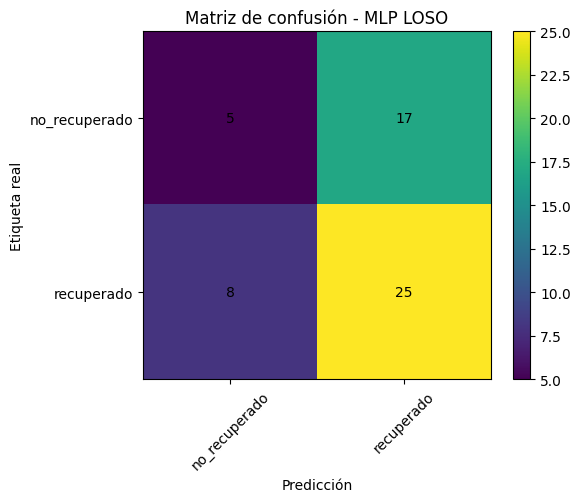

Matriz guardada en:
/content/drive/MyDrive/Proyecto_HRV/outputs/06_matriz_confusion_MLP_LOSO.png


In [34]:
# ============================================================
# 13. MATRIZ DE CONFUSIÓN
# ============================================================

if not predictions_df.empty:

    LABELS = ["no_recuperado", "recuperado"]

    cm = confusion_matrix(
        predictions_df["y_true"],
        predictions_df["y_pred"],
        labels=LABELS
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)

    plt.title("Matriz de confusión - MLP LOSO")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")
    plt.xticks(range(len(LABELS)), LABELS, rotation=45)
    plt.yticks(range(len(LABELS)), LABELS)

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()

    cm_path = os.path.join(OUT_DIR, "06_matriz_confusion_MLP_LOSO.png")
    plt.savefig(cm_path, dpi=300)
    plt.show()

    print("Matriz guardada en:")
    print(cm_path)

else:
    print("No hay predicciones para graficar matriz de confusión.")

In [35]:
# ============================================================
# 14. ENTRENAMIENTO FINAL MLP LOCAL
# ============================================================

from sklearn.preprocessing import LabelEncoder

if recovery_real_df["recovery_label"].nunique() < 2:
    print("No se puede entrenar modelo final: solo hay una clase.")

else:
    # Copia limpia
    recovery_train_df = recovery_real_df.copy()
    recovery_train_df = recovery_train_df.replace([np.inf, -np.inf], np.nan)
    recovery_train_df = recovery_train_df.dropna(
        subset=MODEL_FEATURES + ["recovery_label"]
    )

    # Codificar etiquetas
    final_label_encoder = LabelEncoder()
    recovery_train_df["label_encoded"] = final_label_encoder.fit_transform(
        recovery_train_df["recovery_label"]
    )

    print("Codificación de clases:")
    for original, encoded in zip(
        final_label_encoder.classes_,
        final_label_encoder.transform(final_label_encoder.classes_)
    ):
        print(f"{original} -> {encoded}")

    # Generar sintéticos desde todos los datos reales disponibles
    synth_final = generate_synthetic_by_label(
        real_df=recovery_train_df,
        feature_cols=MODEL_FEATURES,
        label_col="recovery_label",
        n_synth_per_real=N_SYNTH_PER_REAL,
        noise_level=NOISE_LEVEL,
        random_state=42
    )

    # Codificar etiquetas sintéticas con el mismo encoder
    synth_final["label_encoded"] = final_label_encoder.transform(
        synth_final["recovery_label"]
    )

    train_final_df = pd.concat(
        [recovery_train_df, synth_final],
        ignore_index=True
    )

    train_final_df = train_final_df.replace([np.inf, -np.inf], np.nan)
    train_final_df = train_final_df.dropna(
        subset=MODEL_FEATURES + ["label_encoded"]
    )

    X_final = train_final_df[MODEL_FEATURES]
    y_final = train_final_df["label_encoded"].astype(int)

    final_mlp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=16,
            learning_rate_init=0.0005,
            max_iter=500,
            random_state=42,
            early_stopping=False
        ))
    ])

    final_mlp.fit(X_final, y_final)

    model_pack = {
        "model": final_mlp,
        "label_encoder": final_label_encoder,
        "features": MODEL_FEATURES,
        "labels": list(final_label_encoder.classes_),
        "fs_hz": FS_HZ,
        "window_sec": WINDOW_SEC,
        "step_sec": STEP_SEC,
        "recovery_threshold": RECOVERY_THRESHOLD,
        "n_synth_per_real": N_SYNTH_PER_REAL,
        "noise_level": NOISE_LEVEL
    }

    model_path = os.path.join(
        OUT_DIR,
        "07_modelo_local_MLP_recuperacion.joblib"
    )

    joblib.dump(model_pack, model_path)

    print("Modelo local MLP guardado en:")
    print(model_path)

    print("\nFeatures usadas por el modelo:")
    print(MODEL_FEATURES)

    print("\nClases guardadas:")
    print(list(final_label_encoder.classes_))

Codificación de clases:
no_recuperado -> 0
recuperado -> 1
Modelo local MLP guardado en:
/content/drive/MyDrive/Proyecto_HRV/outputs/07_modelo_local_MLP_recuperacion.joblib

Features usadas por el modelo:
['HR_mean', 'RR_mean', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean_delta_basal', 'RR_mean_delta_basal', 'SDNN_delta_basal', 'RMSSD_delta_basal', 'pNN50_delta_basal', 'HR_mean_ratio_basal', 'RR_mean_ratio_basal', 'SDNN_ratio_basal', 'RMSSD_ratio_basal', 'pNN50_ratio_basal']

Clases guardadas:
['no_recuperado', 'recuperado']


In [36]:
import pandas as pd
import os

edge_path = os.path.join(OUT_DIR, "05_dataset_edge_impulse_recuperacion.csv")

edge_df = pd.read_csv(edge_path)

display(edge_df.head())
display(edge_df["label"].value_counts())
print(edge_df.shape)
print(edge_df.columns)

,HR_mean,RR_mean,SDNN,RMSSD,pNN50,HR_mean_delta_basal,RR_mean_delta_basal,SDNN_delta_basal,RMSSD_delta_basal,pNN50_delta_basal,HR_mean_ratio_basal,RR_mean_ratio_basal,SDNN_ratio_basal,RMSSD_ratio_basal,pNN50_ratio_basal,label
0,80.330775,750.894737,57.175306,19.983101,2.702703,8.062000,-85.677845,5.500291,-12.001698,-6.951495,1.111556,0.897585,1.106440,0.624769,0.279951,no_recuperado
1,81.709508,735.512821,30.047219,19.318657,0.000000,9.440734,-101.059761,-21.627797,-12.666141,-9.654198,1.130634,0.879198,0.581465,0.603995,0.000000,no_recuperado
2,78.446413,766.256410,33.769901,23.584674,5.263158,6.177638,-70.316171,-17.905115,-8.400125,-4.391040,1.085481,0.915947,0.653505,0.737371,0.545168,no_recuperado
3,76.947072,781.578947,38.097054,28.181362,13.513514,4.678298,-54.993634,-13.577962,-3.803436,3.859315,1.064735,0.934263,0.737243,0.881086,1.399755,no_recuperado
4,74.460659,809.416667,55.665006,33.325666,17.142857,2.191885,-27.155915,3.989990,1.340867,7.488659,1.030330,0.967539,1.077213,1.041922,1.775689,recuperado


,count
label,
recuperado,132
no_recuperado,88


(220, 16)
Index(['HR_mean', 'RR_mean', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean_delta_basal',
       'RR_mean_delta_basal', 'SDNN_delta_basal', 'RMSSD_delta_basal',
       'pNN50_delta_basal', 'HR_mean_ratio_basal', 'RR_mean_ratio_basal',
       'SDNN_ratio_basal', 'RMSSD_ratio_basal', 'pNN50_ratio_basal', 'label'],
      dtype='object')
